In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Kaggle_AMR_Dataset.csv")
#../data/ tells the notebook to move one folder up and enter the data folder.

df.head()

,Isolate_ID,Genome_Length_BP,GC_Content_Percent,gene_APH(3'')-Ib,gene_APH(3')-Ia,gene_APH(6)-Id,gene_CMY-59,gene_CRP,gene_CTX-M-14,gene_CTX-M-15,...,biosample,bioproject,taxonomy,collection_year,collection_month,collection_season,host_standardized,isolation_source_standardized,total_amr_genes,total_resistance_classes
0,AP035757.1,4784478,50.86,0,0,0,0,1,0,0,...,SAMD00770530,PRJDB18000,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,45,23
1,AP039418.1,5098687,50.58,0,0,0,1,1,0,0,...,SAMD00874696,PRJDB19974,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,47,23
2,AP040249.1,4940609,50.74,0,0,0,0,1,1,0,...,SAMD00548845,PRJDB13852,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,25
3,AP042483.1,5300047,50.74,1,1,1,0,1,0,0,...,SAMD00899021,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,24
4,AP042532.1,5451560,50.52,0,0,0,0,1,0,0,...,SAMD00899031,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23


In [4]:
df.shape
#rows and columns appear on the dataset

(50, 112)

### Dataset Shape Explanation

The output `(50, 112)` means:

- **50 rows** → 50 bacterial samples  
- **112 columns** → genomic features and other variables

In [5]:
df.columns


Index(['Isolate_ID', 'Genome_Length_BP', 'GC_Content_Percent',
       'gene_APH(3'')-Ib', 'gene_APH(3')-Ia', 'gene_APH(6)-Id', 'gene_CMY-59',
       'gene_CRP', 'gene_CTX-M-14', 'gene_CTX-M-15',
       ...
       'biosample', 'bioproject', 'taxonomy', 'collection_year',
       'collection_month', 'collection_season', 'host_standardized',
       'isolation_source_standardized', 'total_amr_genes',
       'total_resistance_classes'],
      dtype='str', length=112)

In [6]:
df.info()
'''This shows:
column types
missing values
whether features are numeric or categorical'''

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Columns: 112 entries, Isolate_ID to total_resistance_classes
dtypes: float64(9), int64(92), str(11)
memory usage: 43.9 KB


'This shows:\ncolumn types\nmissing values\nwhether features are numeric or categorical'

In [7]:
#Check Missing Values
df.isnull().sum()

Isolate_ID                       0
Genome_Length_BP                 0
GC_Content_Percent               0
gene_APH(3'')-Ib                 0
gene_APH(3')-Ia                  0
                                ..
collection_season                0
host_standardized                0
isolation_source_standardized    0
total_amr_genes                  0
total_resistance_classes         0
Length: 112, dtype: int64

In [8]:
#Check the last Columns
df[['total_amr_genes','total_resistance_classes']].head()


,total_amr_genes,total_resistance_classes
0,45,23
1,47,23
2,51,25
3,51,24
4,46,23


In [9]:
#Define MDR target
#In antimicrobial research, MDR (Multi-Drug Resistance) is usually defined as:
#Resistant to ≥ 3 antimicrobial classes
#0->non MDR
#1->MDR
df['MDR'] = (df['total_resistance_classes'] >= 3).astype(int)

C:\Users\Vinayasri\AppData\Local\Temp\ipykernel_12204\4165434613.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MDR'] = (df['total_resistance_classes'] >= 3).astype(int)


In [10]:
#Check Class Distribuution
df['MDR'].value_counts()

MDR
1    50
Name: count, dtype: int64

MDR Class Distribution

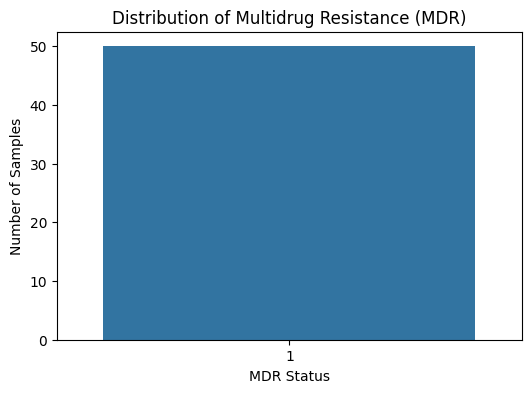

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="MDR", data=df)

plt.title("Distribution of Multidrug Resistance (MDR)")
plt.xlabel("MDR Status")
plt.ylabel("Number of Samples")

plt.show()

Most Common AMR Genes

In [16]:
gene_columns = [col for col in df.columns if col.startswith("gene_")]

gene_counts = df[gene_columns].sum().sort_values(ascending=False)

gene_counts.head(10)

gene_CRP                      50
gene_Escherichia_coli_ampH    50
gene_Escherichia_coli_ampC    50
gene_Escherichia_coli_acrA    50
gene_H-NS                     50
gene_emrK                     50
gene_emrB                     50
gene_emrA                     50
gene_bacA                     50
gene_baeR                     50
dtype: int64

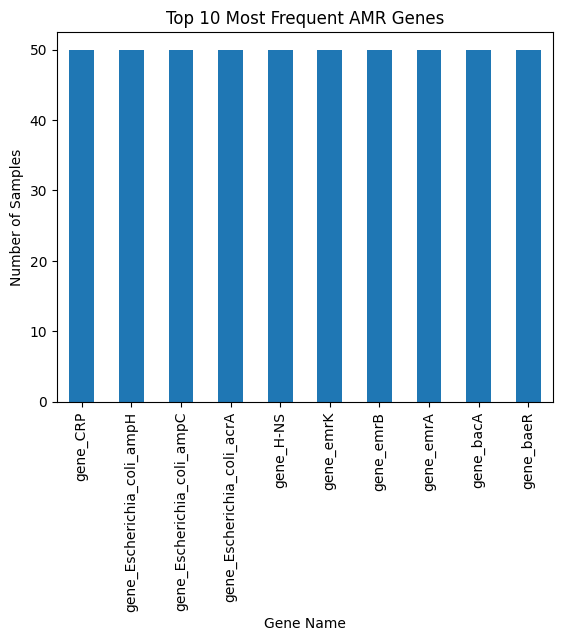

In [17]:
import matplotlib.pyplot as plt

gene_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent AMR Genes")
plt.xlabel("Gene Name")
plt.ylabel("Number of Samples")

plt.show()